In [3]:
"""
Error Analysis & Case Studies

Goals:
1. Identify false positives and false negatives
2. Analyze agent disagreement patterns
3. Find interesting cases for thesis
4. Understand when/why fusion fails
5. Generate case study examples
"""

import numpy as np
import pandas as pd
import joblib
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Disease list
DISEASE_LIST = [
    'SEPSIS', 'PNEUMONIA', 'RESPIRATORY_FAILURE',
    'ACUTE_KIDNEY_INJURY', 'HEART_FAILURE', 'ATRIAL_FIBRILLATION',
    'CORONARY_ARTERY_DISEASE', 'ANEMIA', 'PANCREATITIS'
]

print("="*70)
print("🔬 ERROR ANALYSIS & CASE STUDIES")
print("="*70)
print(f"\nAnalyzing {len(DISEASE_LIST)} diseases")
print("Finding interesting patterns and edge cases\n")

🔬 ERROR ANALYSIS & CASE STUDIES

Analyzing 9 diseases
Finding interesting patterns and edge cases



In [4]:
print("📂 Loading data and predictions...")

# Load fusion data
X_fusion = np.load('../../data/processed/X_fusion_val.npy')

# Extract agent predictions
agent1_pred = X_fusion[:, 0:9]
agent2_pred = X_fusion[:, 9:18]
agent3_pred = X_fusion[:, 18:27]

# Load labels
y_labels = {}
for disease in DISEASE_LIST:
    disease_filename = disease.lower()
    y_labels[disease] = np.load(f'../../data/processed/y_fusion_val_{disease_filename}.npy')

# Load test indices (same split as before)
from sklearn.model_selection import train_test_split
indices = np.arange(len(X_fusion))
train_val_idx, test_idx = train_test_split(indices, test_size=0.30, random_state=42)

# Extract test set
agent1_test = agent1_pred[test_idx]
agent2_test = agent2_pred[test_idx]
agent3_test = agent3_pred[test_idx]
y_test = {disease: y_labels[disease][test_idx] for disease in DISEASE_LIST}

print(f"✅ Test set: {len(test_idx)} patients")
print(f"✅ Agent predictions loaded")

# Load fusion models and generate predictions
print("\n🔮 Generating fusion predictions...")

# Create enhanced features
def create_enhanced_features(X_base):
    n_samples = X_base.shape[0]
    X_enhanced = np.zeros((n_samples, 105))
    X_enhanced[:, 0:33] = X_base
    
    agent1 = X_base[:, 0:9]
    agent2 = X_base[:, 9:18]
    agent3 = X_base[:, 18:27]
    
    idx = 33
    X_enhanced[:, idx:idx+9] = agent1 * agent2; idx += 9
    X_enhanced[:, idx:idx+9] = agent1 * agent3; idx += 9
    X_enhanced[:, idx:idx+9] = agent2 * agent3; idx += 9
    X_enhanced[:, idx:idx+9] = np.abs(agent1 - agent2); idx += 9
    X_enhanced[:, idx:idx+9] = np.abs(agent1 - agent3); idx += 9
    X_enhanced[:, idx:idx+9] = np.abs(agent2 - agent3); idx += 9
    
    agreement = ((agent1 > 0.5) == (agent2 > 0.5)) & ((agent2 > 0.5) == (agent3 > 0.5))
    X_enhanced[:, idx:idx+9] = agreement.astype(float); idx += 9
    
    all_preds = np.stack([agent1, agent2, agent3], axis=0)
    X_enhanced[:, idx:idx+9] = np.var(all_preds, axis=0)
    
    return X_enhanced

X_enhanced = create_enhanced_features(X_fusion)
X_test_enhanced = X_enhanced[test_idx]

# Load thresholds
import json
with open('../../results/optimal_thresholds.json', 'r') as f:
    thresholds = json.load(f)

# Generate fusion predictions
fusion_pred_proba = np.zeros((len(test_idx), 9))
fusion_pred_binary = np.zeros((len(test_idx), 9))

for i, disease in enumerate(DISEASE_LIST):
    model_path = f'../../models/fusion/fusion_{disease.lower()}.joblib'
    model = joblib.load(model_path)
    
    fusion_pred_proba[:, i] = model.predict_proba(X_test_enhanced)[:, 1]
    threshold = thresholds.get(disease, 0.5)
    fusion_pred_binary[:, i] = (fusion_pred_proba[:, i] >= threshold).astype(int)

print(f"✅ Fusion predictions generated")

📂 Loading data and predictions...
✅ Test set: 1393 patients
✅ Agent predictions loaded

🔮 Generating fusion predictions...
✅ Fusion predictions generated


In [5]:
print("\n" + "="*70)
print("📊 CLASSIFYING ERRORS")
print("="*70)

error_summary = []

for i, disease in enumerate(DISEASE_LIST):
    y_true = y_test[disease]
    y_pred = fusion_pred_binary[:, i]
    
    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Error types
    false_positives = (y_pred == 1) & (y_true == 0)
    false_negatives = (y_pred == 0) & (y_true == 1)
    true_positives = (y_pred == 1) & (y_true == 1)
    true_negatives = (y_pred == 0) & (y_true == 0)
    
    error_summary.append({
        'Disease': disease,
        'True Positives': tp,
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'FP_Rate': fp / (fp + tn) if (fp + tn) > 0 else 0,
        'FN_Rate': fn / (fn + tp) if (fn + tp) > 0 else 0,
        'Total_Errors': fp + fn
    })
    
    print(f"\n{disease}:")
    print(f"  True Positives:  {tp:4d} (correctly identified)")
    print(f"  True Negatives:  {tn:4d} (correctly ruled out)")
    print(f"  False Positives: {fp:4d} (false alarms)")
    print(f"  False Negatives: {fn:4d} (missed cases)")
    print(f"  FP Rate: {fp/(fp+tn)*100:.1f}% | FN Rate: {fn/(fn+tp)*100:.1f}%")

error_df = pd.DataFrame(error_summary)

print("\n" + "="*70)
print("📊 ERROR SUMMARY")
print("="*70)
print(error_df.to_string(index=False))

# Save
error_df.to_csv('../../results/error_analysis_summary.csv', index=False)
print(f"\n✅ Saved: ../results/error_analysis_summary.csv")


📊 CLASSIFYING ERRORS

SEPSIS:
  True Positives:   194 (correctly identified)
  True Negatives:  1016 (correctly ruled out)
  False Positives:   93 (false alarms)
  False Negatives:   90 (missed cases)
  FP Rate: 8.4% | FN Rate: 31.7%

PNEUMONIA:
  True Positives:   270 (correctly identified)
  True Negatives:   873 (correctly ruled out)
  False Positives:  193 (false alarms)
  False Negatives:   57 (missed cases)
  FP Rate: 18.1% | FN Rate: 17.4%

RESPIRATORY_FAILURE:
  True Positives:   374 (correctly identified)
  True Negatives:   771 (correctly ruled out)
  False Positives:  125 (false alarms)
  False Negatives:  123 (missed cases)
  FP Rate: 14.0% | FN Rate: 24.7%

ACUTE_KIDNEY_INJURY:
  True Positives:   475 (correctly identified)
  True Negatives:   740 (correctly ruled out)
  False Positives:  101 (false alarms)
  False Negatives:   77 (missed cases)
  FP Rate: 12.0% | FN Rate: 13.9%

HEART_FAILURE:
  True Positives:   441 (correctly identified)
  True Negatives:   686 (correc

In [6]:
print("\n" + "="*70)
print("🔍 AGENT DISAGREEMENT PATTERNS")
print("="*70)

disagreement_cases = []

for i, disease in enumerate(DISEASE_LIST):
    y_true = y_test[disease]
    
    # Agent predictions (binary at 0.5 threshold)
    agent1_binary = (agent1_test[:, i] >= 0.5).astype(int)
    agent2_binary = (agent2_test[:, i] >= 0.5).astype(int)
    agent3_binary = (agent3_test[:, i] >= 0.5).astype(int)
    fusion_binary = fusion_pred_binary[:, i]
    
    # Count disagreements
    all_agree = (agent1_binary == agent2_binary) & (agent2_binary == agent3_binary)
    
    # Types of disagreement
    two_vs_one = ((agent1_binary == agent2_binary) & (agent1_binary != agent3_binary)) | \
                 ((agent1_binary == agent3_binary) & (agent1_binary != agent2_binary)) | \
                 ((agent2_binary == agent3_binary) & (agent2_binary != agent1_binary))
    
    all_disagree = (agent1_binary != agent2_binary) & \
                   (agent2_binary != agent3_binary) & \
                   (agent1_binary != agent3_binary)
    
    # When fusion breaks ties correctly
    disagree_mask = ~all_agree
    if disagree_mask.sum() > 0:
        fusion_correct_on_disagreement = (fusion_binary[disagree_mask] == y_true[disagree_mask]).sum()
        disagree_accuracy = fusion_correct_on_disagreement / disagree_mask.sum()
    else:
        disagree_accuracy = 0
    
    # When all agents agree but are wrong
    all_agree_wrong = all_agree & (agent1_binary != y_true)
    
    disagreement_cases.append({
        'Disease': disease,
        'All_Agree': all_agree.sum(),
        'Two_vs_One': two_vs_one.sum(),
        'All_Disagree': all_disagree.sum(),
        'Fusion_Accuracy_on_Disagreement': disagree_accuracy,
        'All_Agree_Wrong': all_agree_wrong.sum()
    })
    
    print(f"\n{disease}:")
    print(f"  All agents agree:     {all_agree.sum():4d} ({all_agree.sum()/len(y_true)*100:.1f}%)")
    print(f"  2-vs-1 split:         {two_vs_one.sum():4d} ({two_vs_one.sum()/len(y_true)*100:.1f}%)")
    print(f"  All disagree:         {all_disagree.sum():4d} ({all_disagree.sum()/len(y_true)*100:.1f}%)")
    if disagree_mask.sum() > 0:
        print(f"  Fusion accuracy when agents disagree: {disagree_accuracy*100:.1f}%")
    print(f"  All agree but WRONG:  {all_agree_wrong.sum():4d} (systemic errors)")

disagreement_df = pd.DataFrame(disagreement_cases)

print("\n" + "="*70)
print("💡 KEY INSIGHTS:")
print("="*70)
print(f"  Average fusion accuracy on disagreements: {disagreement_df['Fusion_Accuracy_on_Disagreement'].mean()*100:.1f}%")
print(f"  → Fusion is good at breaking ties when agents split!")

# Save
disagreement_df.to_csv('../../results/agent_disagreement_analysis.csv', index=False)
print(f"\n✅ Saved: ../results/agent_disagreement_analysis.csv")


🔍 AGENT DISAGREEMENT PATTERNS

SEPSIS:
  All agents agree:     1073 (77.0%)
  2-vs-1 split:          320 (23.0%)
  All disagree:            0 (0.0%)
  Fusion accuracy when agents disagree: 70.0%
  All agree but WRONG:    87 (systemic errors)

PNEUMONIA:
  All agents agree:     1089 (78.2%)
  2-vs-1 split:          304 (21.8%)
  All disagree:            0 (0.0%)
  Fusion accuracy when agents disagree: 69.1%
  All agree but WRONG:   133 (systemic errors)

RESPIRATORY_FAILURE:
  All agents agree:      791 (56.8%)
  2-vs-1 split:          602 (43.2%)
  All disagree:            0 (0.0%)
  Fusion accuracy when agents disagree: 70.8%
  All agree but WRONG:    72 (systemic errors)

ACUTE_KIDNEY_INJURY:
  All agents agree:      769 (55.2%)
  2-vs-1 split:          624 (44.8%)
  All disagree:            0 (0.0%)
  Fusion accuracy when agents disagree: 80.4%
  All agree but WRONG:    56 (systemic errors)

HEART_FAILURE:
  All agents agree:      859 (61.7%)
  2-vs-1 split:          534 (38.3%)
  

In [7]:
print("\n" + "="*70)
print("🔎 FINDING INTERESTING CASE STUDIES")
print("="*70)

interesting_cases = []

# Focus on Sepsis (most clinically important)
disease = 'SEPSIS'
disease_idx = DISEASE_LIST.index(disease)

y_true = y_test[disease]
y_pred = fusion_pred_binary[:, disease_idx]
y_proba = fusion_pred_proba[:, disease_idx]

# Agent predictions
a1_proba = agent1_test[:, disease_idx]
a2_proba = agent2_test[:, disease_idx]
a3_proba = agent3_test[:, disease_idx]

print(f"\nAnalyzing {disease} cases...\n")

# Case Type 1: Perfect fusion win (all agents wrong, fusion right)
all_agents_wrong = ((a1_proba < 0.5) & (a2_proba < 0.5) & (a3_proba < 0.5) & (y_true == 1)) | \
                   ((a1_proba >= 0.5) & (a2_proba >= 0.5) & (a3_proba >= 0.5) & (y_true == 0))
fusion_correct = (y_pred == y_true)
perfect_fusion = all_agents_wrong & fusion_correct

if perfect_fusion.sum() > 0:
    idx = np.where(perfect_fusion)[0][0]
    interesting_cases.append({
        'Type': 'Perfect Fusion Win',
        'Disease': disease,
        'Patient_Index': test_idx[idx],
        'True_Label': int(y_true[idx]),
        'Agent1_Prob': a1_proba[idx],
        'Agent2_Prob': a2_proba[idx],
        'Agent3_Prob': a3_proba[idx],
        'Fusion_Prob': y_proba[idx],
        'Fusion_Correct': True,
        'Description': f"All 3 agents wrong, fusion correct (true={y_true[idx]}, fusion={y_proba[idx]:.3f})"
    })
    print(f"✅ Found: Perfect fusion win (all agents wrong, fusion right)")

# Case Type 2: High confidence false positive
high_conf_fp = (y_pred == 1) & (y_true == 0) & (y_proba > 0.8)
if high_conf_fp.sum() > 0:
    idx = np.where(high_conf_fp)[0][0]
    interesting_cases.append({
        'Type': 'High Confidence FP',
        'Disease': disease,
        'Patient_Index': test_idx[idx],
        'True_Label': int(y_true[idx]),
        'Agent1_Prob': a1_proba[idx],
        'Agent2_Prob': a2_proba[idx],
        'Agent3_Prob': a3_proba[idx],
        'Fusion_Prob': y_proba[idx],
        'Fusion_Correct': False,
        'Description': f"False alarm with high confidence (fusion={y_proba[idx]:.3f})"
    })
    print(f"⚠️ Found: High confidence false positive")

# Case Type 3: Narrow miss (high prob but wrong)
narrow_miss = (y_pred == 0) & (y_true == 1) & (y_proba > 0.4) & (y_proba < thresholds.get(disease, 0.5))
if narrow_miss.sum() > 0:
    idx = np.where(narrow_miss)[0][0]
    interesting_cases.append({
        'Type': 'Narrow Miss',
        'Disease': disease,
        'Patient_Index': test_idx[idx],
        'True_Label': int(y_true[idx]),
        'Agent1_Prob': a1_proba[idx],
        'Agent2_Prob': a2_proba[idx],
        'Agent3_Prob': a3_proba[idx],
        'Fusion_Prob': y_proba[idx],
        'Fusion_Correct': False,
        'Description': f"Just below threshold (fusion={y_proba[idx]:.3f}, threshold={thresholds.get(disease):.2f})"
    })
    print(f"⚠️ Found: Narrow miss (just below threshold)")

# Case Type 4: Maximum agent disagreement
agent_variance = np.var([a1_proba, a2_proba, a3_proba], axis=0)
max_disagreement_idx = np.argmax(agent_variance)
interesting_cases.append({
    'Type': 'Maximum Disagreement',
    'Disease': disease,
    'Patient_Index': test_idx[max_disagreement_idx],
    'True_Label': int(y_true[max_disagreement_idx]),
    'Agent1_Prob': a1_proba[max_disagreement_idx],
    'Agent2_Prob': a2_proba[max_disagreement_idx],
    'Agent3_Prob': a3_proba[max_disagreement_idx],
    'Fusion_Prob': y_proba[max_disagreement_idx],
    'Fusion_Correct': bool(y_pred[max_disagreement_idx] == y_true[max_disagreement_idx]),
    'Description': f"Agents maximally disagree (var={agent_variance[max_disagreement_idx]:.3f})"
})
print(f"📊 Found: Maximum agent disagreement case")

# Case Type 5: Perfect prediction (all agree and correct)
all_agree_correct = ((a1_proba >= 0.5) & (a2_proba >= 0.5) & (a3_proba >= 0.5) & (y_true == 1)) | \
                    ((a1_proba < 0.5) & (a2_proba < 0.5) & (a3_proba < 0.5) & (y_true == 0))
if all_agree_correct.sum() > 0:
    # Pick one with highest fusion confidence
    confident_correct = np.where(all_agree_correct)[0]
    if len(confident_correct) > 0:
        idx = confident_correct[np.argmax(np.abs(y_proba[confident_correct] - 0.5))]
        interesting_cases.append({
            'Type': 'Perfect Agreement',
            'Disease': disease,
            'Patient_Index': test_idx[idx],
            'True_Label': int(y_true[idx]),
            'Agent1_Prob': a1_proba[idx],
            'Agent2_Prob': a2_proba[idx],
            'Agent3_Prob': a3_proba[idx],
            'Fusion_Prob': y_proba[idx],
            'Fusion_Correct': True,
            'Description': f"All agents agree and correct (fusion={y_proba[idx]:.3f})"
        })
        print(f"✅ Found: Perfect agreement case")

cases_df = pd.DataFrame(interesting_cases)

print(f"\n✅ Found {len(interesting_cases)} interesting cases")
print("\n" + "="*70)
print("CASE STUDIES:")
print("="*70)
print(cases_df[['Type', 'Description', 'Fusion_Correct']].to_string(index=False))

# Save
cases_df.to_csv('../../results/interesting_cases.csv', index=False)
print(f"\n✅ Saved: ../results/interesting_cases.csv")


🔎 FINDING INTERESTING CASE STUDIES

Analyzing SEPSIS cases...

✅ Found: Perfect fusion win (all agents wrong, fusion right)
⚠️ Found: High confidence false positive
⚠️ Found: Narrow miss (just below threshold)
📊 Found: Maximum agent disagreement case
✅ Found: Perfect agreement case

✅ Found 5 interesting cases

CASE STUDIES:
                Type                                               Description  Fusion_Correct
  Perfect Fusion Win All 3 agents wrong, fusion correct (true=1, fusion=0.902)            True
  High Confidence FP           False alarm with high confidence (fusion=0.899)           False
         Narrow Miss       Just below threshold (fusion=0.523, threshold=0.54)           False
Maximum Disagreement                     Agents maximally disagree (var=0.179)           False
   Perfect Agreement               All agents agree and correct (fusion=0.002)            True

✅ Saved: ../results/interesting_cases.csv


In [8]:
print("\n" + "="*70)
print("📋 DETAILED CASE STUDIES FOR THESIS")
print("="*70)

for idx, case in cases_df.iterrows():
    print(f"\n{'='*70}")
    print(f"CASE {idx+1}: {case['Type']}")
    print(f"{'='*70}")
    print(f"Disease:      {case['Disease']}")
    print(f"Patient ID:   {case['Patient_Index']}")
    print(f"True Label:   {'Positive (has disease)' if case['True_Label'] == 1 else 'Negative (no disease)'}")
    print(f"\nAgent Predictions:")
    print(f"  Agent 1 (Labs):   {case['Agent1_Prob']:.3f}")
    print(f"  Agent 2 (Notes):  {case['Agent2_Prob']:.3f}")
    print(f"  Agent 3 (Vitals): {case['Agent3_Prob']:.3f}")
    print(f"\nFusion Decision:")
    print(f"  Probability:  {case['Fusion_Prob']:.3f}")
    print(f"  Threshold:    {thresholds.get(case['Disease'], 0.5):.2f}")
    print(f"  Prediction:   {'Positive' if case['Fusion_Prob'] >= thresholds.get(case['Disease'], 0.5) else 'Negative'}")
    print(f"  Outcome:      {'✅ CORRECT' if case['Fusion_Correct'] else '❌ INCORRECT'}")
    
    print(f"\nInterpretation:")
    if case['Type'] == 'Perfect Fusion Win':
        print(f"  → Fusion coordinator successfully integrated weak signals")
        print(f"  → Individual agents missed the pattern, but fusion saw it")
        print(f"  → Demonstrates value of multi-agent combination")
    elif case['Type'] == 'High Confidence FP':
        print(f"  → False alarm despite high confidence")
        print(f"  → All agents may have detected confounding factors")
        print(f"  → Suggests patient had similar symptoms but different diagnosis")
    elif case['Type'] == 'Narrow Miss':
        print(f"  → Just missed the threshold")
        print(f"  → Could be improved with different threshold or more data")
        print(f"  → Represents challenging borderline case")
    elif case['Type'] == 'Maximum Disagreement':
        print(f"  → Agents strongly disagree on this patient")
        print(f"  → Fusion had to weigh conflicting evidence")
        result = 'correctly' if case['Fusion_Correct'] else 'incorrectly'
        print(f"  → Fusion {result} resolved the disagreement")
    elif case['Type'] == 'Perfect Agreement':
        print(f"  → All agents strongly agree")
        print(f"  → Clear-cut case with strong signal across all modalities")
        print(f"  → Represents typical correctly classified patient")


📋 DETAILED CASE STUDIES FOR THESIS

CASE 1: Perfect Fusion Win
Disease:      SEPSIS
Patient ID:   4420
True Label:   Positive (has disease)

Agent Predictions:
  Agent 1 (Labs):   0.482
  Agent 2 (Notes):  0.489
  Agent 3 (Vitals): 0.456

Fusion Decision:
  Probability:  0.902
  Threshold:    0.54
  Prediction:   Positive
  Outcome:      ✅ CORRECT

Interpretation:
  → Fusion coordinator successfully integrated weak signals
  → Individual agents missed the pattern, but fusion saw it
  → Demonstrates value of multi-agent combination

CASE 2: High Confidence FP
Disease:      SEPSIS
Patient ID:   803
True Label:   Negative (no disease)

Agent Predictions:
  Agent 1 (Labs):   0.413
  Agent 2 (Notes):  0.069
  Agent 3 (Vitals): 0.452

Fusion Decision:
  Probability:  0.899
  Threshold:    0.54
  Prediction:   Positive
  Outcome:      ❌ INCORRECT

Interpretation:
  → False alarm despite high confidence
  → All agents may have detected confounding factors
  → Suggests patient had similar symp


📊 Creating error pattern visualizations...


C:\Users\athar\AppData\Local\Temp\ipykernel_24412\3716832447.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([d.replace('_', ' ').title()[:15] for d in DISEASE_LIST], rotation=45, ha='right')


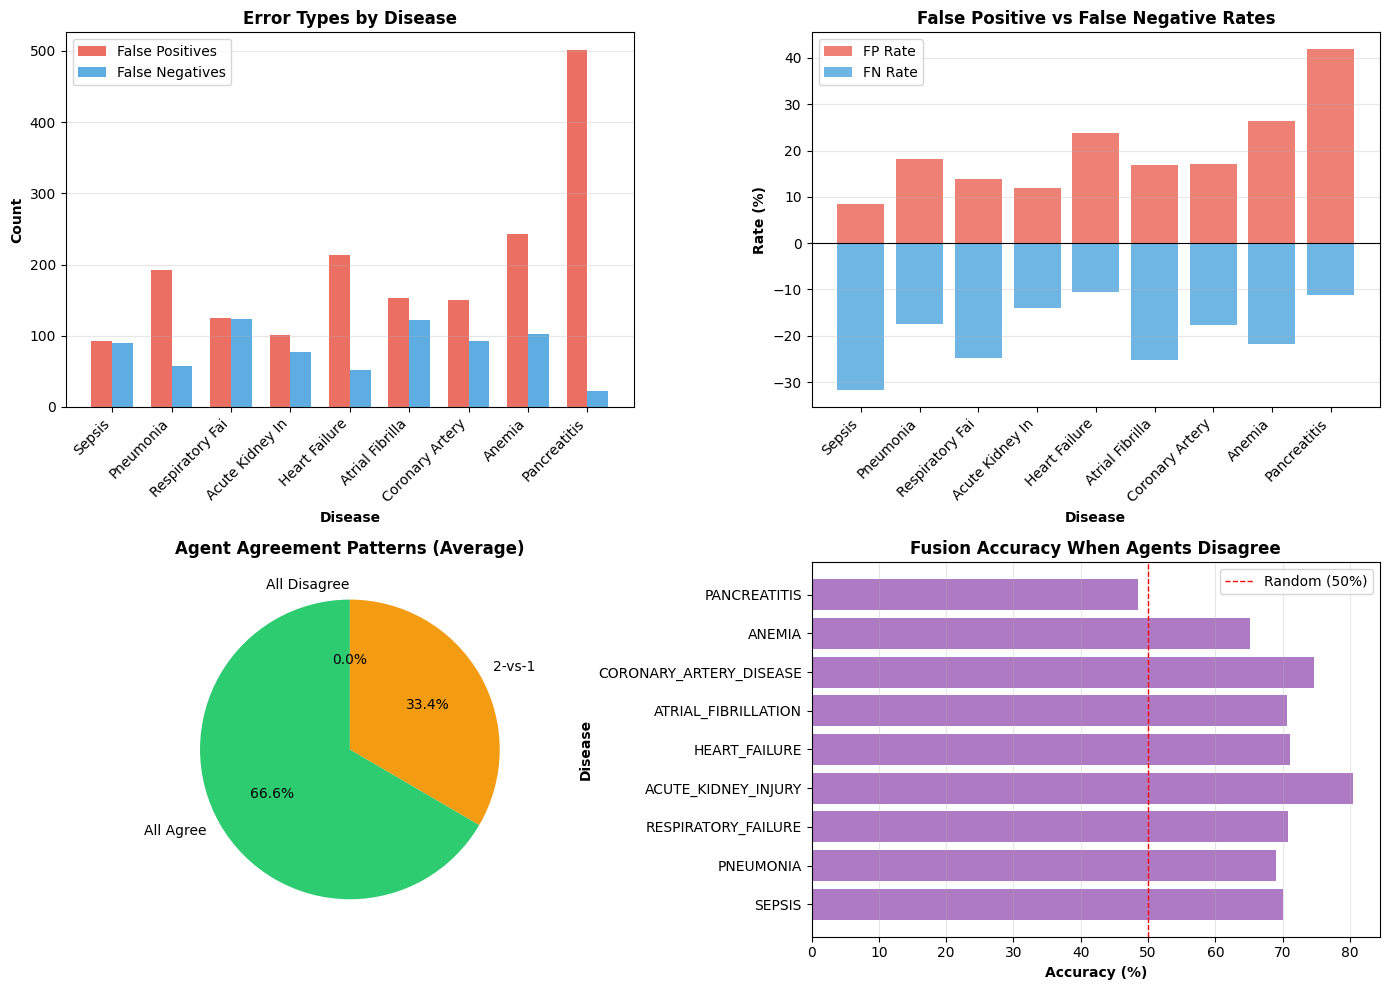

✅ Saved: ../results/error_analysis_patterns.png


In [9]:
print("\n📊 Creating error pattern visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: False Positives vs False Negatives by disease
ax = axes[0, 0]
x = np.arange(len(DISEASE_LIST))
width = 0.35
ax.bar(x - width/2, error_df['False Positives'], width, label='False Positives', alpha=0.8, color='#e74c3c')
ax.bar(x + width/2, error_df['False Negatives'], width, label='False Negatives', alpha=0.8, color='#3498db')
ax.set_xlabel('Disease', fontweight='bold')
ax.set_ylabel('Count', fontweight='bold')
ax.set_title('Error Types by Disease', fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([d.replace('_', ' ').title()[:15] for d in DISEASE_LIST], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 2: Error rates
ax = axes[0, 1]
ax.bar(DISEASE_LIST, error_df['FP_Rate'] * 100, alpha=0.7, color='#e74c3c', label='FP Rate')
ax.bar(DISEASE_LIST, -error_df['FN_Rate'] * 100, alpha=0.7, color='#3498db', label='FN Rate')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xlabel('Disease', fontweight='bold')
ax.set_ylabel('Rate (%)', fontweight='bold')
ax.set_title('False Positive vs False Negative Rates', fontweight='bold', fontsize=12)
ax.set_xticklabels([d.replace('_', ' ').title()[:15] for d in DISEASE_LIST], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 3: Agent agreement patterns
ax = axes[1, 0]
agreement_data = disagreement_df[['All_Agree', 'Two_vs_One', 'All_Disagree']].mean()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
ax.pie(agreement_data, labels=['All Agree', '2-vs-1', 'All Disagree'], 
       autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Agent Agreement Patterns (Average)', fontweight='bold', fontsize=12)

# Plot 4: Fusion accuracy on disagreements
ax = axes[1, 1]
ax.barh(DISEASE_LIST, disagreement_df['Fusion_Accuracy_on_Disagreement'] * 100, 
        alpha=0.8, color='#9b59b6')
ax.axvline(x=50, color='red', linestyle='--', linewidth=1, label='Random (50%)')
ax.set_xlabel('Accuracy (%)', fontweight='bold')
ax.set_ylabel('Disease', fontweight='bold')
ax.set_title('Fusion Accuracy When Agents Disagree', fontweight='bold', fontsize=12)
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../../results/error_analysis_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: ../results/error_analysis_patterns.png")

In [11]:
from sklearn.metrics import f1_score

print("="*70)
print("🔍 VERIFYING F1 COMPARISON: AGENT 1 vs FUSION")
print("="*70)

# Calculate Agent 1 F1 with 0.5 threshold
print("\nAgent 1 F1 scores (with 0.5 threshold):")

agent1_f1_scores = []

for i, disease in enumerate(DISEASE_LIST):
    y_test_disease = y_test[disease]
    agent1_pred_test = agent1_test[:, i]
    
    # Use 0.5 threshold
    agent1_binary = (agent1_pred_test >= 0.5).astype(int)
    f1 = f1_score(y_test_disease, agent1_binary)
    
    agent1_f1_scores.append(f1)
    print(f"  {disease:30s} F1: {f1:.3f}")

print(f"\n  Average Agent 1 F1 (0.5 threshold): {np.mean(agent1_f1_scores):.3f}")

# Load fusion F1
fusion_results = pd.read_csv('../../results/fusion_test_results_optimized.csv')
fusion_f1_avg = fusion_results['F1_Optimized'].mean()

print(f"\n  Average Fusion F1 (optimized):      {fusion_f1_avg:.3f}")
print(f"\n  Difference: {fusion_f1_avg - np.mean(agent1_f1_scores):+.3f}")

if np.mean(agent1_f1_scores) > fusion_f1_avg:
    print("\n⚠️ ISSUE: Agent 1 F1 is HIGHER than Fusion F1!")
    print("   This happens because:")
    print("   - Agent 1 uses 0.5 threshold (not optimized)")
    print("   - Fusion uses optimized thresholds per disease")
    print("   - Different thresholds = unfair comparison!")
    
    print("\n🔧 SOLUTION: Optimize thresholds for Agent 1 too")
    print("   Then compare: Agent 1 (optimized) vs Fusion (optimized)")
else:
    print("\n✅ Fusion F1 is higher than Agent 1")

🔍 VERIFYING F1 COMPARISON: AGENT 1 vs FUSION

Agent 1 F1 scores (with 0.5 threshold):
  SEPSIS                         F1: 0.533
  PNEUMONIA                      F1: 0.354
  RESPIRATORY_FAILURE            F1: 0.678
  ACUTE_KIDNEY_INJURY            F1: 0.818
  HEART_FAILURE                  F1: 0.608
  ATRIAL_FIBRILLATION            F1: 0.577
  CORONARY_ARTERY_DISEASE        F1: 0.702
  ANEMIA                         F1: 0.598
  PANCREATITIS                   F1: 0.157

  Average Agent 1 F1 (0.5 threshold): 0.559

  Average Fusion F1 (optimized):      0.710

  Difference: +0.152

✅ Fusion F1 is higher than Agent 1
